In [1]:
import pickle as pkl

import pandas as pd

from normalize_vendor import normalize_vendor

#### Objective: 
Analyze and select the top 100 vendors for crawling.

#### Depends on:

In [2]:
fname = "./data/01-parsed-amounts-and-dates.parquet"

#### Generates:

In [ ]:
top_100_vendors_fname = "./data/top_100_vendors.csv"

-----------------

In [3]:
df = pd.read_parquet(fname)

In [4]:
df.head()

,cohort,agency_number,agency_name,holder_last_name,holder_first_initial,amount,vendor,mcc,parsed_amount,transaction_date,posted_date
0,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,890,NACAS,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,890.00,2013-07-30,2013-07-31
1,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,368.96,SHERATON HOTEL,SHERATON,368.96,2013-07-30,2013-07-31
2,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,J,165.82,SEARS.COM 9300,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,165.82,2013-07-29,2013-07-31
3,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,96.39,WAL-MART #0137,"GROCERY STORES,AND SUPERMARKETS",96.39,2013-07-30,2013-07-31
4,201307,1000,OKLAHOMA STATE UNIVERSITY,Mauro-Herrera,M,125.96,STAPLES DIRECT,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",125.96,2013-07-30,2013-07-31


In [5]:
df["normalized_vendor"] = df["vendor"].apply(normalize_vendor)

In [6]:
df.head()

,cohort,agency_number,agency_name,holder_last_name,holder_first_initial,amount,vendor,mcc,parsed_amount,transaction_date,posted_date,normalized_vendor
0,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,890,NACAS,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,890.00,2013-07-30,2013-07-31,NACAS
1,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,368.96,SHERATON HOTEL,SHERATON,368.96,2013-07-30,2013-07-31,SHERATON HOTEL
2,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,J,165.82,SEARS.COM 9300,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,165.82,2013-07-29,2013-07-31,SEARS
3,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,96.39,WAL-MART #0137,"GROCERY STORES,AND SUPERMARKETS",96.39,2013-07-30,2013-07-31,WALMART
4,201307,1000,OKLAHOMA STATE UNIVERSITY,Mauro-Herrera,M,125.96,STAPLES DIRECT,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",125.96,2013-07-30,2013-07-31,STAPLES


In [7]:
df[df.normalized_vendor == ""].head()

,cohort,agency_number,agency_name,holder_last_name,holder_first_initial,amount,vendor,mcc,parsed_amount,transaction_date,posted_date,normalized_vendor
9273,201307,1000,OKLAHOMA STATE UNIVERSITY,Ross,S,68.4,IM3 INC,DENTAL/LABORATORY/MEDICAL/OPHTHALMIC HOSP EQIP...,68.40,2013-07-17,2013-07-24,
14590,201308,1000,OKLAHOMA STATE UNIVERSITY,Snyder,G,14.18,C2G,"COMMERCIAL EQUIPMENT, NOT ELSEWHERE CLASSIFIED",14.18,2013-07-31,2013-08-01,
15215,201308,1000,OKLAHOMA STATE UNIVERSITY,Wyant,B,78.17,C2G,"COMMERCIAL EQUIPMENT, NOT ELSEWHERE CLASSIFIED",78.17,2013-08-08,2013-08-09,
18366,201308,1000,OKLAHOMA STATE UNIVERSITY,Dzialowski,A,395,N A L M S,CATALOG MERCHANTS,395.00,2013-08-21,2013-08-23,
20025,201309,1000,OKLAHOMA STATE UNIVERSITY,Snyder,G,288.88,C2G,"COMMERCIAL EQUIPMENT, NOT ELSEWHERE CLASSIFIED",288.88,2013-09-27,2013-09-30,


In [8]:
df = df[df.normalized_vendor != ""]

In [16]:
df[df.normalized_vendor == "WALMART"].head()

,cohort,agency_number,agency_name,holder_last_name,holder_first_initial,amount,vendor,mcc,parsed_amount,transaction_date,posted_date,normalized_vendor
3,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,96.39,WAL-MART #0137,"GROCERY STORES,AND SUPERMARKETS",96.39,2013-07-30,2013-07-31,WALMART
6,201307,1000,OKLAHOMA STATE UNIVERSITY,Mays,B,19.87,WAL-MART #0137,"GROCERY STORES,AND SUPERMARKETS",19.87,2013-07-30,2013-07-31,WALMART
19,201307,1000,OKLAHOMA STATE UNIVERSITY,MONTGOMERY,R,18.97,WAL-MART #0121,"GROCERY STORES,AND SUPERMARKETS",18.97,2013-07-30,2013-07-31,WALMART
58,201307,1000,OKLAHOMA STATE UNIVERSITY,Dillard,C,104.86,WAL-MART #0137,"GROCERY STORES,AND SUPERMARKETS",104.86,2013-07-25,2013-07-26,WALMART
108,201307,1000,OKLAHOMA STATE UNIVERSITY,Haseley,S,571.68,WAL-MART #4241,"GROCERY STORES,AND SUPERMARKETS",571.68,2013-07-28,2013-07-29,WALMART


<Axes: xlabel='normalized_vendor'>

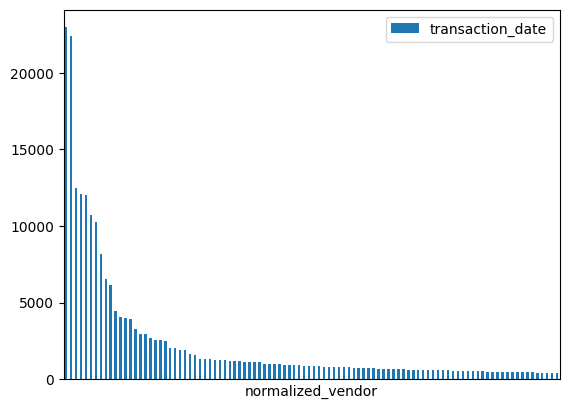

In [10]:
df.groupby("normalized_vendor").count().sort_values(
    "transaction_date", ascending=False
).head(100).plot(y="transaction_date", kind="bar", xticks=[])

In [11]:
top_100_vendors = list(
    df.groupby("normalized_vendor")
    .count()
    .sort_values("transaction_date", ascending=False)
    .head(100)
    .index
)

In [12]:
print(top_100_vendors)

['AMAZON', 'STAPLES', 'WALMART', 'GRAINGER', 'AMERICAN AI', 'JOURNYHSE', 'LOWES', 'FEDEX', 'AT&T', 'AGENT FEE', 'BILL WARREN OFFICE PRODUC', 'OFFICEMAX', 'SOUTHWES', 'VWR', 'UNITED', 'DELTA AIR', 'OREILLY AUTO', 'AIRGAS CENTRAL', 'THE HOME DEPOT', 'FASTENAL', 'MCKESSON MEDICAL SUPPLY', 'DMI DELL HIGHER EDUC', 'OKLA RESORTS PARKS GOLF', 'OFFICE DEPOT', 'SUPERCENTER', 'SIGMA ALDRICH', 'HOBBY LOBBY', 'EUREKA WATER', 'SOUTH CENTRAL INDUSTRIES', 'MSC', 'TFS FISHERSCI ECOM HUS', 'DMI DELL GOVT', 'ATT BUS PHONE PMT', 'NEWEGG', 'NAPA AUTO PARTS', 'UPS', 'INTERNATIONAL TRANSACTION', 'VOSS LIGHTING OKLAHOMA', 'MCMASTER CARR', 'DEPT CORRECTIONS', 'STILLWATER MILLING COMP', 'BEST BUY', 'CENTRAL OKLAHOMAWINLSN', 'QUILL', 'XPEDX  PAPER', 'REXEL', 'B&C BUSINESS PRODUCTS', 'HOLIDAY INN EXPRESS', 'KINNUNEN SALES RENT', 'FEDERAL COPRORATION', 'COX OKLAHOMA COMM', 'HUNZICKER BROTHERS', 'INVITROGEN', 'EQUIPMENT', 'DEARINGER PRINTING TROP', 'OKLAHOMA CITY WINNELSO', 'UNITED REFRIG', 'GALT FOUNDATION', 'DEP

In [13]:
with open(top_100_vendors_fname, "w") as f:
    f.write("\n".join(top_100_vendors) + "\n")

In [14]:
len(df[df.vendor.str.contains("|".join(top_100_vendors))]) / len(df)

0.42151960030049873